In [1]:
import sys
import os

# Adds the parent directory (root) to the Python path
sys.path.append(os.path.abspath(os.path.join('..')))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import holidays

In [3]:
df = pd.read_csv('../data/raw/cleaned_transactions.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,transaction_type
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Sale
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Sale
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Sale


In [4]:
df.shape

(514547, 9)

In [5]:
# filter for sales only
df = df[df["Quantity"] > 0]
df.shape

(504731, 9)

In [6]:
max_qrt = df.sort_values(by = "Quantity", ascending = False)
max_qrt["Quantity"].quantile([0.50, 0.75, 0.90, 0.95, 0.99])

0.50      3.0
0.75     12.0
0.90     24.0
0.95     32.0
0.99    120.0
Name: Quantity, dtype: float64

In [7]:
max_qrt.describe()

,Quantity,Price,Customer ID
count,504731.000000,504731.000000,400916.000000
mean,11.516923,4.274692,15361.544074
std,87.337497,64.093333,1680.635823
min,1.000000,0.001000,12346.000000
25%,1.000000,1.250000,13985.000000
50%,3.000000,2.100000,15311.000000
75%,12.000000,4.210000,16805.000000
max,19152.000000,25111.090000,18287.000000


In [8]:
# filter for bulk purchases
df = max_qrt[max_qrt["Quantity"] <= 120]
df.shape

(500275, 9)

In [9]:
print(df['InvoiceDate'].max())
print(df['InvoiceDate'].min()) 

2010-12-09 20:01:00
2009-12-01 07:45:00


## Feature Engineering

### Aggregate Data to Daily Demand

In [10]:
# Convert 'InvoiceDate' to datetime and extract day from timestamp
df['InvoiceDate'] = pd.to_datetime(df["InvoiceDate"]).dt.normalize()

def aggregate_daily_demand(df):

    daily_demand = (
        df.groupby(
            ["InvoiceDate", "StockCode"],
            as_index=False
        )
        .agg(
            Quantity=("Quantity", "sum"),
            Price=("Price", "mean")
        )
    )

    return daily_demand

daily_demand_df = aggregate_daily_demand(df)

In [11]:
daily_demand_df.head()

,InvoiceDate,StockCode,Quantity,Price
0,2009-12-01,10002,12,0.850
1,2009-12-01,10120,60,0.210
2,2009-12-01,10123C,3,1.300
3,2009-12-01,10123G,2,1.700
4,2009-12-01,10125,5,1.275


In [12]:
daily_demand_df.shape

(264964, 4)

I will use the functions I have already written in features subfolder

In [13]:
from features.calendars import create_calendar_features
from features.easter_christmas import create_christmas_features
from features.holidays import create_holiday_features
from features.lag_features import create_lag_features
from features.momentum import create_momentum_features
from features.rolling import create_rolling_features
from features.sku_features import create_sku_features
from features.create_target import create_target
from features.product_lifecycle import create_product_lifecycle_features
from features.feature_pipeline import build_demand_features

In [14]:
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "pyyaml"])

0

In [15]:
import pydantic
from config.feature_config import (DATE_COL, 
                                   TARGET_COL, 
                                   PRICE_COL, 
                                   PRODUCT_COL,
                                   DROP_COLS
)

In [16]:
print(DATE_COL)
print(PRICE_COL)

InvoiceDate
Price


In [17]:

demand_features = build_demand_features(daily_demand_df)

In [18]:
demand_features.head()

,InvoiceDate,StockCode,Quantity,Price,price_ratio,day_of_week,day_of_month,week_of_year,month,quarter,...,rolling_mean_28,rolling_std_28,momentum_7_28,momentum_14_28,sku_mean_qty,sku_median_qty,sku_std_qty,sku_avg_price,sku_cv,target
0,2009-12-01,10002,12,0.850,0.883125,1,1,49,12,4,...,NaN,NaN,NaN,NaN,20.558011,12.0,23.471098,0.962491,1.141701,2.564949
1,2009-12-01,10120,60,0.210,0.825070,1,1,49,12,4,...,NaN,NaN,NaN,NaN,11.595238,5.0,13.877618,0.254524,1.196838,4.110874
2,2009-12-01,10123C,3,1.300,1.578456,1,1,49,12,4,...,NaN,NaN,NaN,NaN,6.884615,2.0,15.317111,0.823590,2.224831,1.386294
3,2009-12-01,10123G,2,1.700,1.763767,1,1,49,12,4,...,NaN,NaN,NaN,NaN,3.307692,1.0,3.750214,0.963846,1.133785,1.098612
4,2009-12-01,10125,5,1.275,1.250383,1,1,49,12,4,...,NaN,NaN,NaN,NaN,13.328125,14.5,12.502768,1.019687,0.938074,1.791759


In [19]:
# Did the item sell at all yesterday?
demand_features["was_active_yesterday"] = (demand_features["lag_1"] > 0).astype(int)

In [20]:
demand_features.shape

(264964, 41)

In [21]:
demand_features['StockCode'].nunique()

4245

In [22]:
demand_features['InvoiceDate'].max()

Timestamp('2010-12-09 00:00:00')

## Build and Train LIGHTGBM Model

In [23]:
# timebased train-valid split
def train_valid_split(
    df,
    date_col,
    split_date
):

    train_df = df[
        df[date_col] < split_date
    ]

    valid_df = df[
        df[date_col] >= split_date
    ]

    return train_df, valid_df

# split the features
train_df, valid_df = train_valid_split(
    demand_features,
    date_col='InvoiceDate',
    split_date='2010-10-01'
)

print(f"Train shape: {train_df.shape}")
print(f"Valid shape: {valid_df.shape}")

Train shape: (196149, 41)
Valid shape: (68815, 41)


In [24]:
import joblib
from lightgbm import LGBMRegressor
import lightgbm as lgb
from sklearn.metrics import (mean_squared_error, 
                             mean_absolute_error, 
                             mean_absolute_percentage_error)

# model parameters
params = {
    'objective': "regression",
    'metric': "rmse",
    #'num_leaves': 31,
    'boosting_type': "gbdt",
    'learning_rate': 0.05,
     'n_estimators': 600,
     'colsample_bytree': 0.8,
     'subsample': 0.8,
     'random_state': 42
}

In [25]:
X_train = train_df.drop(columns = DROP_COLS, errors = "ignore")
y_train = train_df[TARGET_COL]

X_test = valid_df.drop(columns =DROP_COLS, errors = "ignore")
y_test = valid_df[TARGET_COL]   

In [26]:
X_train.columns

Index(['Price', 'price_ratio', 'day_of_week', 'day_of_month', 'week_of_year',
       'month', 'quarter', 'is_weekend', 'days_to_christmas',
       'christmas_window', 'christmas_countdown', 'days_to_easter',
       'easter_window', 'is_holiday', 'holiday_name', 'days_to_next_holiday',
       'days_since_previous_holiday', 'days_since_first_sale', 'lag_1',
       'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7',
       'rolling_mean_14', 'rolling_std_14', 'rolling_mean_28',
       'rolling_std_28', 'momentum_7_28', 'momentum_14_28', 'sku_mean_qty',
       'sku_median_qty', 'sku_std_qty', 'sku_avg_price', 'sku_cv',
       'was_active_yesterday'],
      dtype='str')

In [27]:
# Define your categorical features from your config
categorical_cols = ["holiday_name"]

# create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols,)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data,
                        categorical_feature=categorical_cols,)

In [28]:
#Train the model
model = lgb.train(params, train_data, num_boost_round=1000, 
                  valid_sets=[test_data], callbacks=[lgb.early_stopping(stopping_rounds=50)])


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006929 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6102
[LightGBM] [Info] Number of data points in the train set: 196149, number of used features: 34
[LightGBM] [Info] Start training from score 14.707488
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[245]	valid_0's rmse: 19.6247


In [29]:
# make predictions
predictions = model.predict(X_test)

## Evaluation

In [30]:
from models.evaluate import evaluate, wmape_sklearn, weighted_mape

evaluate(y_true = y_test, y_pred = predictions)

{'MAE': 10.920707307400297,
 'RMSE': 19.62465025171107,
 'wmape_sklearn': np.float64(0.637729279428139),
 'WMAPE': np.float64(0.637729279428139)}

Evaluation metrics reveal a significant diagnostic pattern: 

- RMSE is extremely high.
- This dramatic gap indicates that while the model is highly accurate on most standard days, it is making a few massive prediction errors on specific outlier days. Because RMSE squares the errors before averaging them, large mistakes penalize this metric severely.

- This mathematical divergence usually happens when the model completely misses unexpected demand spikes, such as promotional events, bulk commercial orders, or the exact peak of a holiday.

## Feature Importance

Plot the feature importance to see what drove these predictions

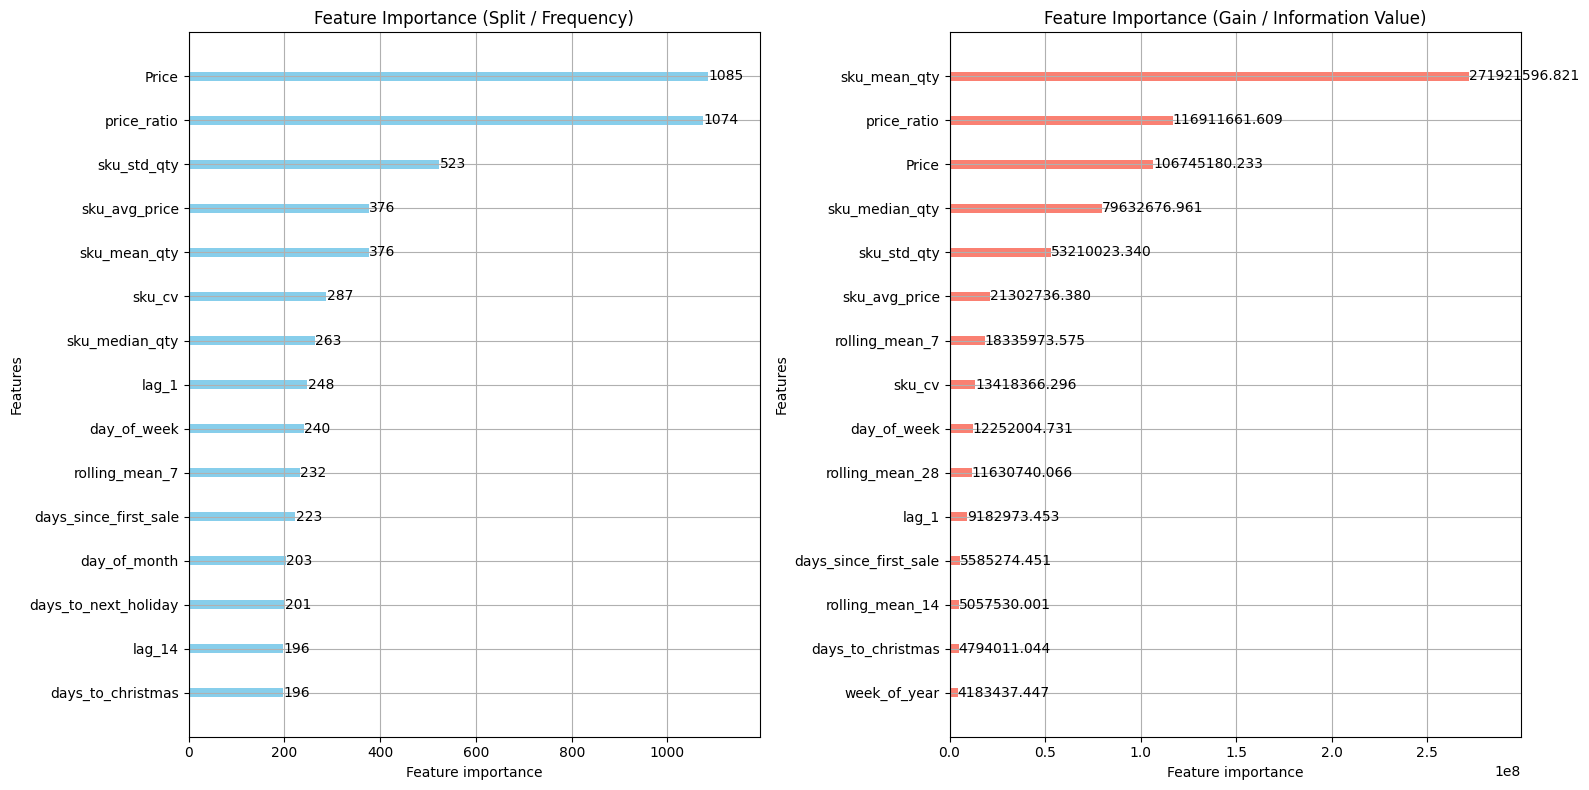

In [31]:
import matplotlib.pyplot as plt

# Configure a side-by-side plotting area
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Plot Split Importance (Frequency of use)
lgb.plot_importance(
    model, 
    importance_type="split", 
    max_num_features=15, 
    ax=ax[0], 
    title="Feature Importance (Split / Frequency)",
    color="skyblue"
)

# Plot Gain Importance (Contribution to accuracy)
lgb.plot_importance(
    model, 
    importance_type="gain", 
    max_num_features=15, 
    ax=ax[1], 
    title="Feature Importance (Gain / Information Value)",
    color="salmon"
)

plt.tight_layout()
plt.show()


## Loss Function Adjustment

By default, LightGBM optimizes for RMSE (objective: 'regression'). I want the model to focus less on penalizing these extreme outliers and instead optimize for overall percentage accuracy. Therefore, I change LightGBM objective parameter

In [32]:
# Update parameters to fix underfitting
params = {
    "objective": "tweedie",  
    "metric": "rmse",
    "tweedie_variance_power": 1.5,  # 1.5 is standard for retail sales
    "learning_rate": 0.01,
    "num_leaves": 63,
}

# Run training with more boosting rounds
model = lgb.train(
    params,
    train_data,
    num_boost_round=2000,
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=150)],
)

# make predictions
predictions = model.predict(X_test)

# evaluate
print("\n")
print("Eval metrics")

evaluate(y_true = y_test, y_pred = predictions)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008875 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6102
[LightGBM] [Info] Number of data points in the train set: 196149, number of used features: 34
[LightGBM] [Info] Start training from score 2.688357
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[1766]	valid_0's rmse: 19.0535


Eval metrics


{'MAE': 10.262832044519312,
 'RMSE': 19.053480604024312,
 'wmape_sklearn': np.float64(0.5993117753653401),
 'WMAPE': np.float64(0.5993117753653401)}

In [33]:
# Update training parameters to handle outliers better
params = {
    'objective': "huber",
    'metric': "rmse",
    #'num_leaves': 31,
    #'boosting_type': "gbdt",
    'learning_rate': 0.045,
     'n_estimators': 500,
     #'colsample_bytree': 0.8,
     #'subsample': 0.8,
     'random_state': 42,
     'verbosity': 0
}

#Train the model
model = lgb.train(params, train_data, num_boost_round=1000, 
                  valid_sets=[test_data], callbacks=[lgb.early_stopping(stopping_rounds=50)])

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's rmse: 25.6314


In [34]:
# make predictions
predictions = model.predict(X_test)
evaluate(y_true = y_test, y_pred = predictions)

{'MAE': 11.22256792861729,
 'RMSE': 25.63138412705345,
 'wmape_sklearn': np.float64(0.6553568333069975),
 'WMAPE': np.float64(0.6553568333069975)}

Adjusting objective to Huber loss improved weighted mape 

## Log Transform Target

In [35]:
# log transform target
y_train_log = np.log1p(train_df[TARGET_COL])
y_test_log = valid_df[TARGET_COL] 

# create train data with log target
# create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train_log, categorical_feature=categorical_cols,)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data,
                        categorical_feature=categorical_cols,)

In [36]:
# Train model using y_train_log with regression
# model parameters
params1 = {
    'objective': "regression",
    'metric': "rmse",
    #'num_leaves': 31,
    'boosting_type': "gbdt",
    'learning_rate': 0.05,
     'n_estimators': 600,
     'colsample_bytree': 0.8,
     'subsample': 0.8,
     'random_state': 42
}

model = lgb.train(params1, train_data, num_boost_round=1000, 
                  valid_sets=[test_data], 
                  callbacks=[lgb.early_stopping(stopping_rounds=50)])

# Inverse transform predictions before evaluating
log_predictions = model.predict(X_test)
final_predictions = np.expm1(log_predictions)

# evaluate
print("\n")
print("Eval metrics")

evaluate(y_true = y_test, y_pred = final_predictions)

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[599]	valid_0's rmse: 31.3425


Eval metrics


{'MAE': 9.668391557382447,
 'RMSE': 19.950151045722915,
 'wmape_sklearn': np.float64(0.5645986297005151),
 'WMAPE': np.float64(0.5645986297005151)}

### Plot feature importance again

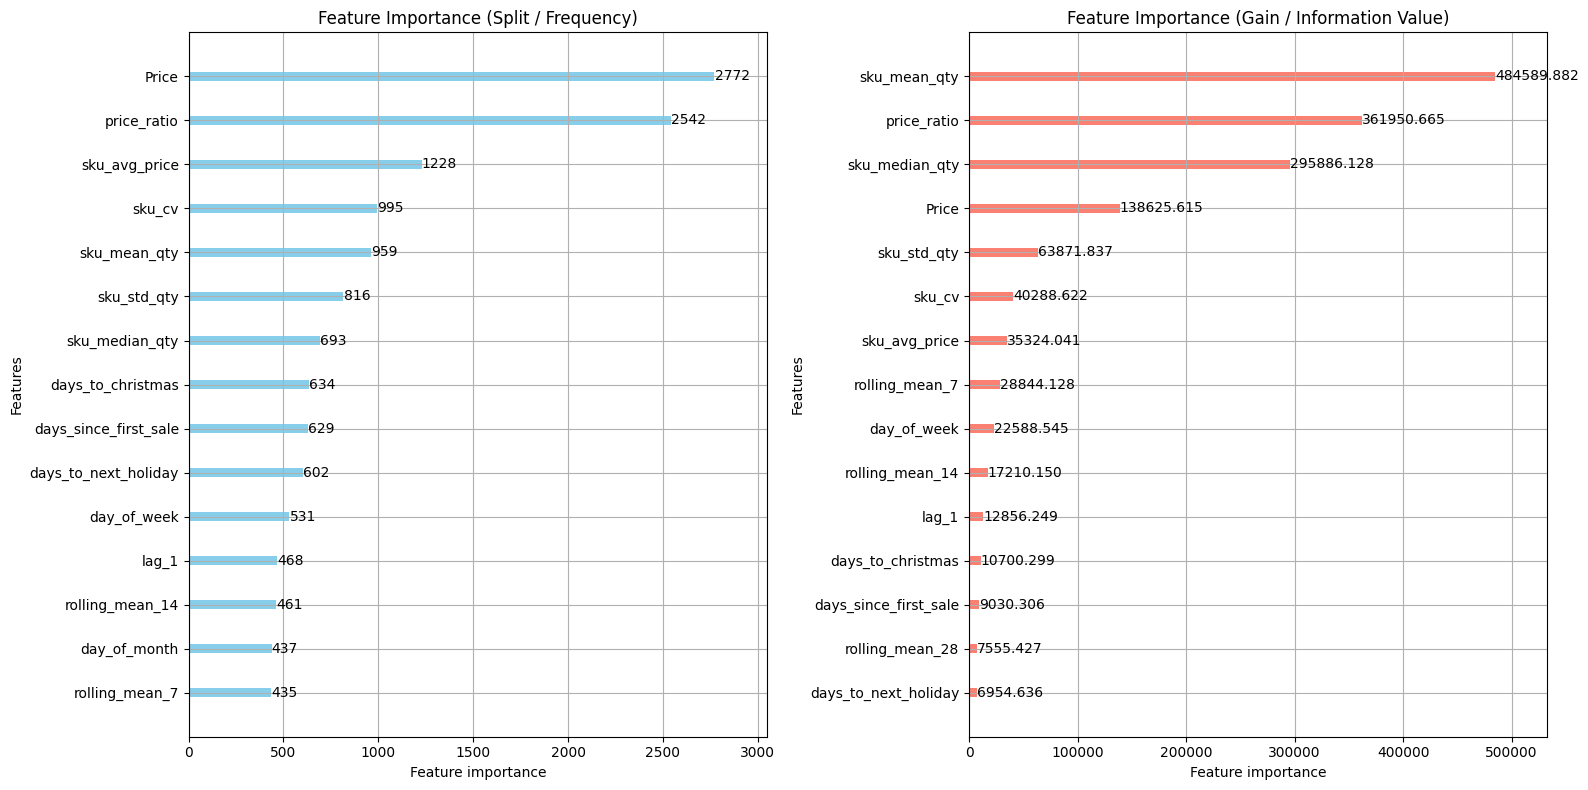

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Plot Split Importance (Frequency of use)
lgb.plot_importance(
    model, 
    importance_type="split", 
    max_num_features=15, 
    ax=ax[0], 
    title="Feature Importance (Split / Frequency)",
    color="skyblue"
)

# Plot Gain Importance (Contribution to accuracy)
lgb.plot_importance(
    model, 
    importance_type="gain", 
    max_num_features=15, 
    ax=ax[1], 
    title="Feature Importance (Gain / Information Value)",
    color="salmon"
)

plt.tight_layout()
plt.show()


In [38]:
# Merge predictions directly back into test_df
test_df = valid_df.copy()
test_df["predicted_demand"] = predictions

# rename target column for clarity during aggregation
test_df = test_df.rename(columns={"Quantity": "actual_demand"})

# verify the alignment side-by-side
print(test_df[["InvoiceDate", "StockCode", "actual_demand", "predicted_demand"]].head())

       InvoiceDate StockCode  actual_demand  predicted_demand
196149  2010-10-01     11001             16         15.606622
196150  2010-10-01     16048             24         12.262649
196151  2010-10-01    16161P             25         25.524529
196152  2010-10-01     16236              6         13.218086
196153  2010-10-01     16237              5         22.608500


In [39]:
#create weekly timestamp
test_df["week"] = test_df["InvoiceDate"].dt.to_period("W")

# aggregate weekly
weekly_df = (
    test_df.groupby(["week"])[["actual_demand", "predicted_demand"]].sum().reset_index()
)

# Calculate WMAPE on the weekly aggregation
weekly_wmape = weighted_mape(weekly_df["actual_demand"], weekly_df["predicted_demand"])
print(f"Weekly Aggregated Retail WMAPE: {weekly_wmape:.2%}")

Weekly Aggregated Retail WMAPE: 41.18%
